In [3]:
import os
import pandas as pd
import plotnine as pln

In [6]:
dir_path = '../experiments/fineTune/esm2_t33_650M_UR50D/viral/pool_split/CVB3_3D_Alvarez/version_967232839'

def read_CSVLogger1(dir_path):
    df = pd.read_csv(f"{dir_path}/metrics.csv")
    train_df = df[df["train_loss"].notna()].copy().drop(columns=["val_loss", "val_r2", "val_rho"])
    val_df = df[df["val_loss"].notna()].copy().drop(columns=["train_loss", "train_r2", "train_rho"])
    res = pd.merge(train_df, val_df, on=["epoch", "step"])
    res.rename(columns={"epoch": "Epoch"}, inplace=True)
    res['Epoch'] = res['Epoch'].astype(int) + 1
    
    # Filter rows where the difference between train_r2 and val_r2 is smaller than 0.1
    # diff = res[res['train_r2'] - res['val_r2'] < 0.6]
    # best_epoch = diff['val_r2'].idxmax()
    
    # diff = (res['train_r2'] - res['val_r2']).abs()
    # best_epoch = (res['val_r2'] / (diff + 1e-6)).idxmax()  # high val_r2 and low gap

    # Just selecting the highest r2
    best_epoch =  res['val_r2'].idxmax() 

    res['best_epoch'] = best_epoch + 1
    return res

res = read_CSVLogger1(dir_path)
res

,Epoch,step,train_loss,train_r2,train_rho,val_loss,val_r2,val_rho,best_epoch
0,1,229,1.761914,-0.094614,-0.007982,1.563022,-0.001028,0.410019,20
1,2,459,1.638411,-0.018934,0.009684,1.596547,-0.022499,0.459219,20
2,3,689,1.644183,-0.023544,0.014734,1.556213,0.003333,0.488491,20
3,4,919,1.635841,-0.017382,0.019018,1.537719,0.015177,0.401494,20
4,5,1149,1.626257,-0.011366,0.076245,1.674765,-0.072593,0.464178,20
5,6,1379,1.426423,0.113693,0.346888,1.095947,0.298107,0.657911,20
6,7,1609,0.951603,0.408046,0.623969,0.883353,0.434261,0.691293,20
7,8,1839,0.690109,0.570737,0.706120,0.728448,0.533470,0.706718,20
8,9,2069,0.554576,0.655236,0.740180,0.612759,0.607562,0.739104,20
9,10,2299,0.463295,0.712092,0.758430,0.580356,0.628315,0.728244,20


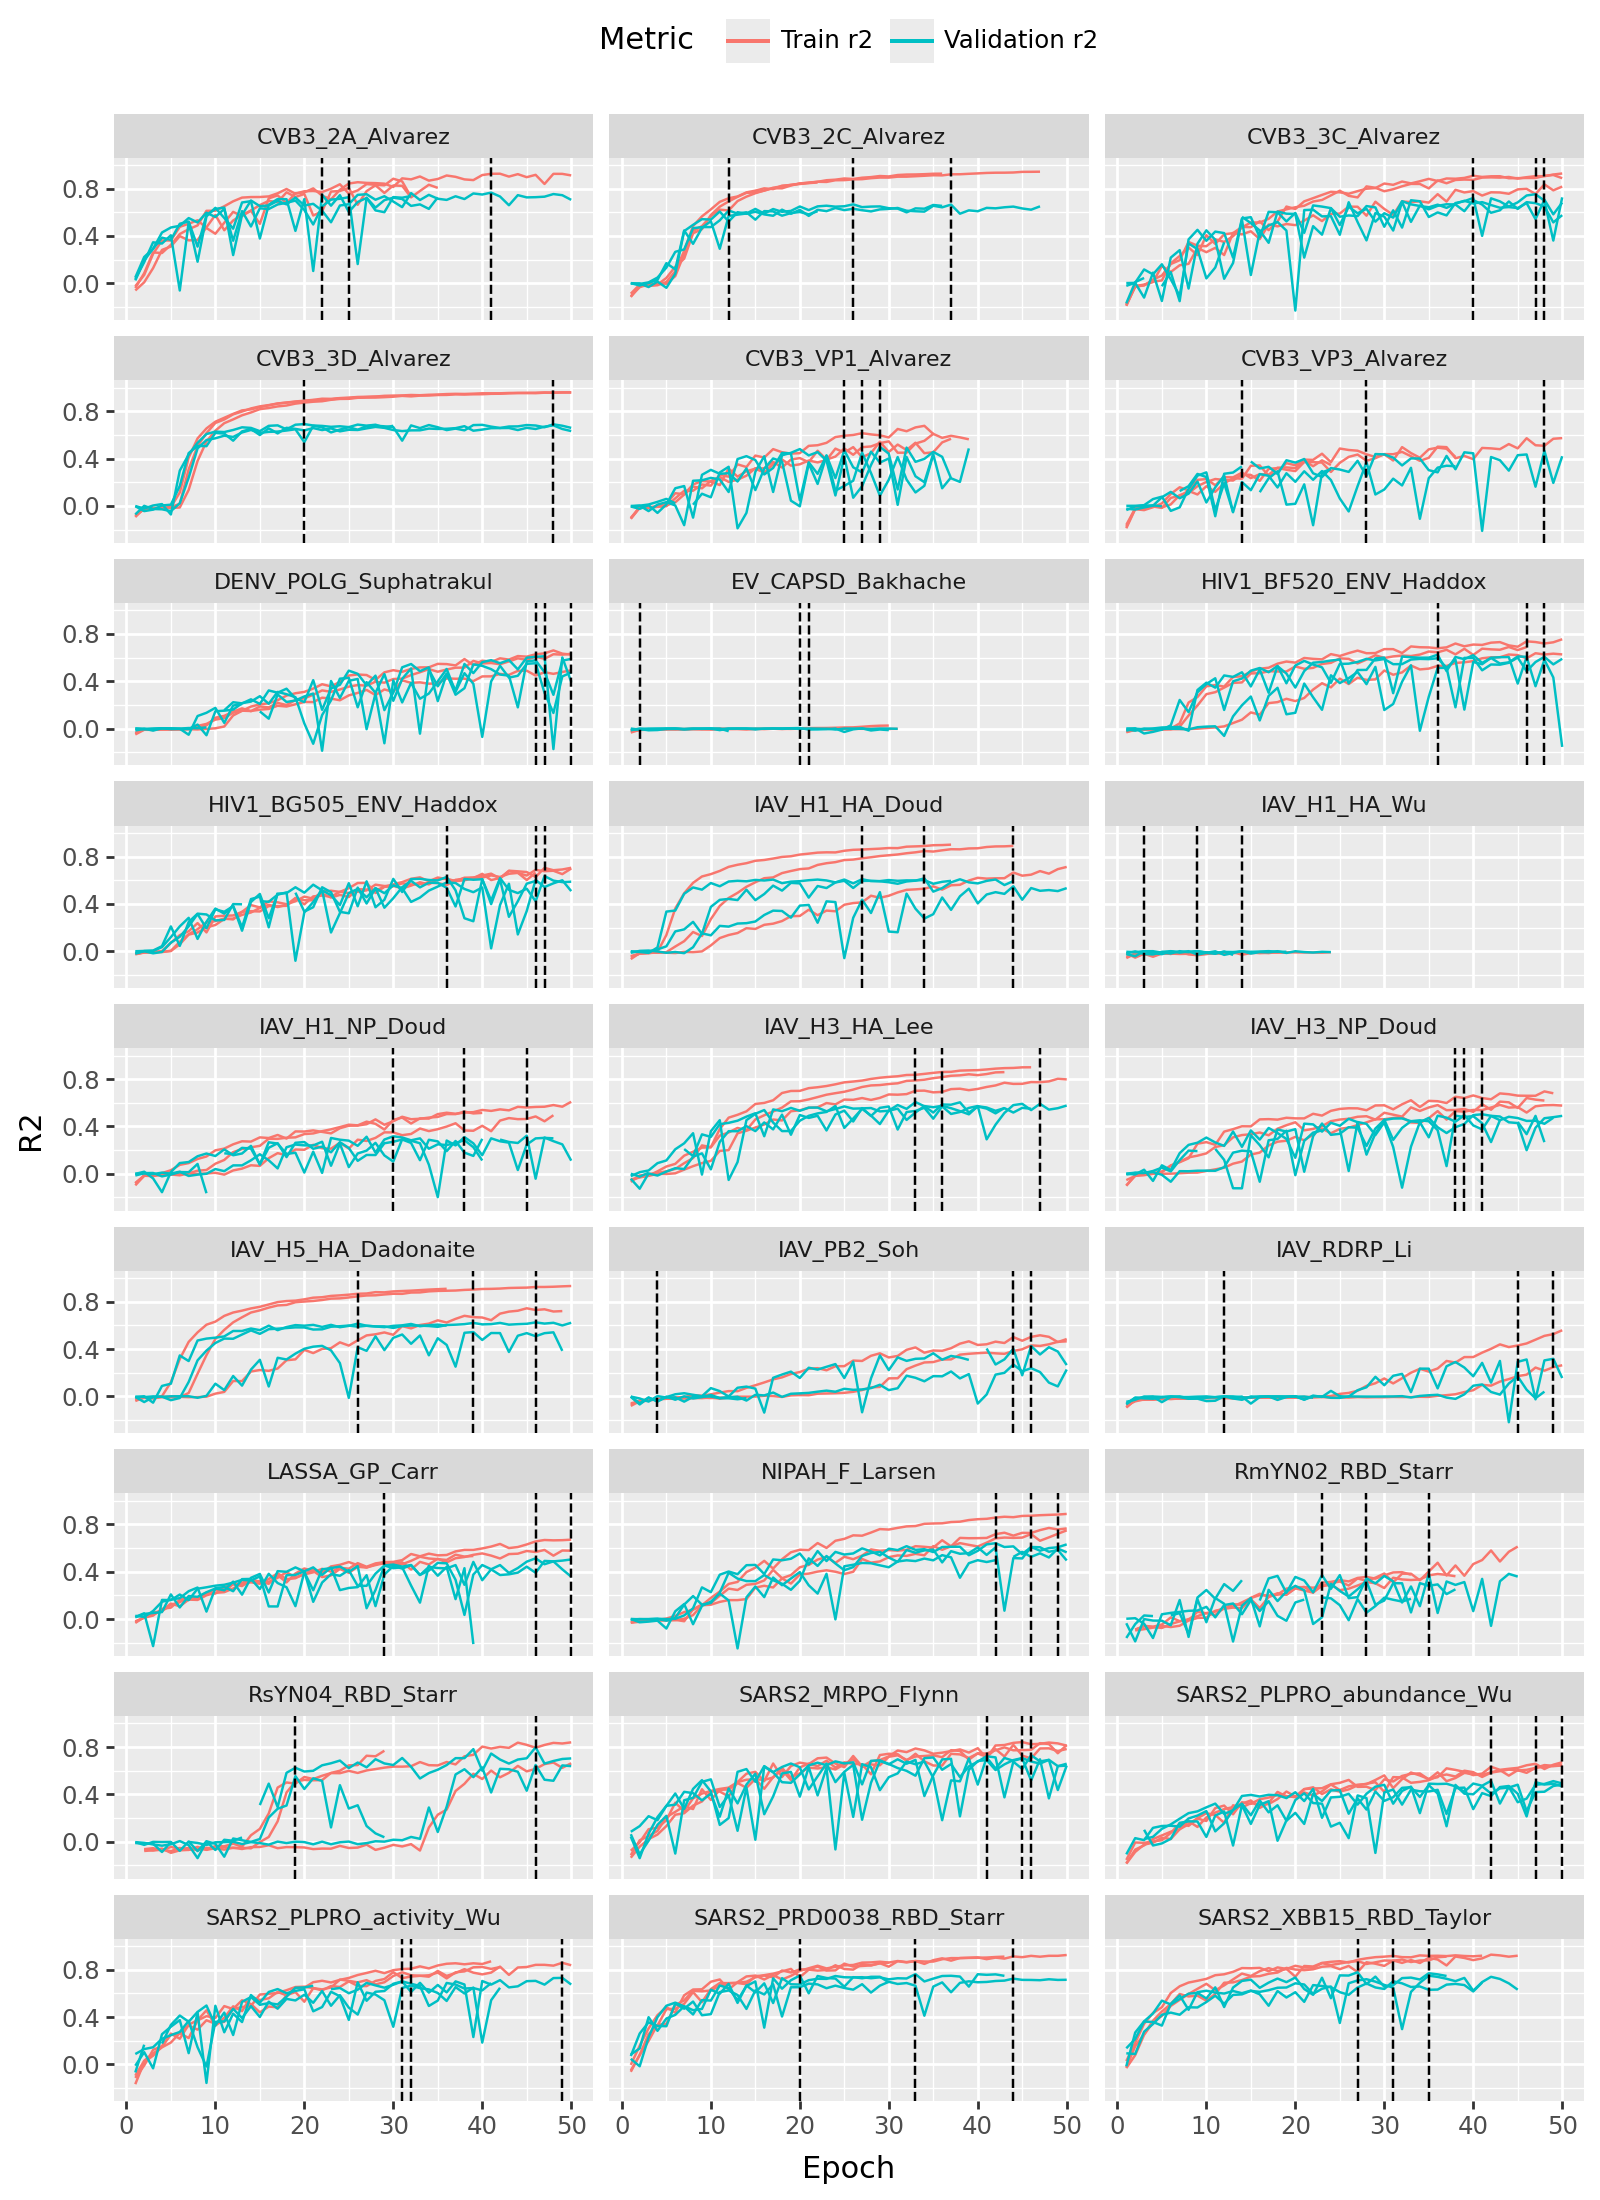

In [10]:
res_dir = f'../experiments/fineTune/esm2_t33_650M_UR50D/viral/pool_split'

res = pd.DataFrame()
for dataset in os.listdir(f'{res_dir}/'):
    for fold, version in enumerate(os.listdir(f'{res_dir}/{dataset}/'), start=1):
        seed = version.split('_')[-1]
        dataset_dir = f'{res_dir}/{dataset}/{version}'
        df = read_CSVLogger1(dataset_dir)
        df['Dataset'] = dataset
        df['fold'] = fold
        df['seed'] = seed
        res = pd.concat([res, df], ignore_index=True).reset_index(drop=True)


plot = (pln.ggplot(res)
        + pln.geom_line(pln.aes(x='Epoch', y='train_r2', color="'Train r2'", group="fold"))
        + pln.geom_line(pln.aes(x='Epoch', y='val_r2', color="'Validation r2'", group="fold"))
        + pln.geom_vline(pln.aes(xintercept='best_epoch'), color='black', linetype='dashed')
        + pln.xlab('Epoch')
        + pln.ylab('R2')        
        + pln.facet_wrap('Dataset',  ncol=3)
        + pln.labs(color="Metric")
        + pln.ylim(-0.25, 1)
        + pln.theme(legend_position='top', figure_size=(8, 11), strip_text=pln.element_text(size=8)) 
        )
plot#.save(filename='../experiments/finetune_r2.png', dpi=600)

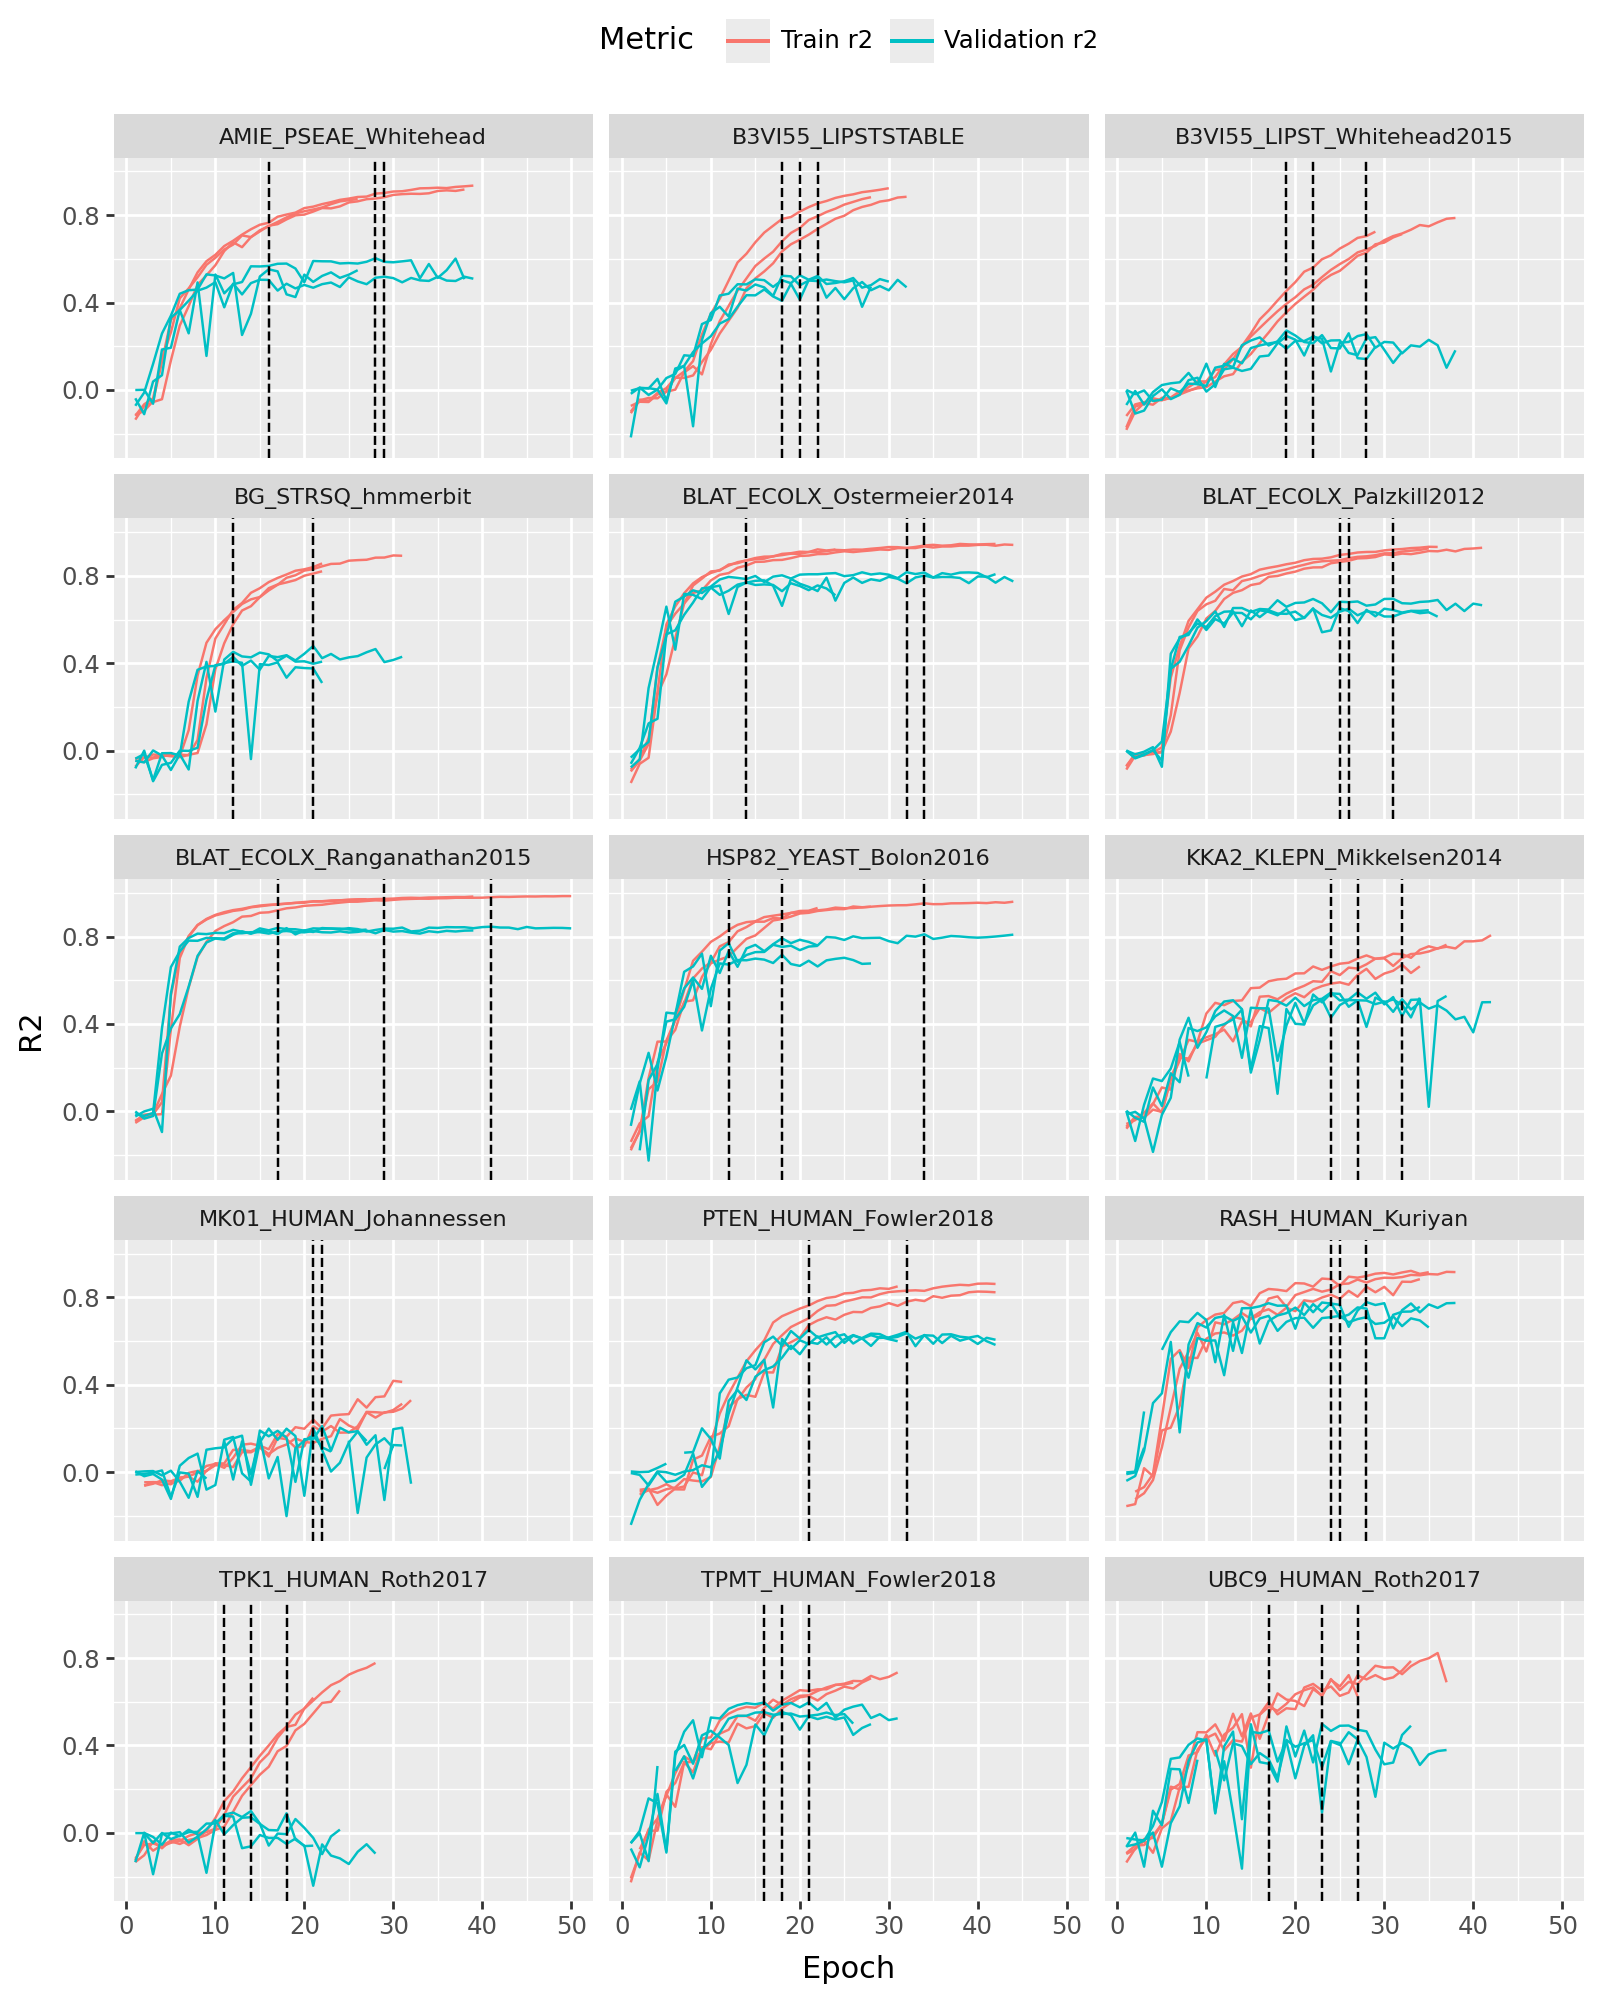

In [12]:
res_dir = f'../experiments/fineTune/esm2_t33_650M_UR50D/cellular/pool_split'

res = pd.DataFrame()
for dataset in os.listdir(f'{res_dir}/'):
    for fold, version in enumerate(os.listdir(f'{res_dir}/{dataset}/'), start=1):
        seed = version.split('_')[-1]
        dataset_dir = f'{res_dir}/{dataset}/{version}'
        df = read_CSVLogger1(dataset_dir)
        df['Dataset'] = dataset
        df['fold'] = fold
        df['seed'] = seed
        res = pd.concat([res, df], ignore_index=True).reset_index(drop=True)


plot = (pln.ggplot(res)
        + pln.geom_line(pln.aes(x='Epoch', y='train_r2', color="'Train r2'", group="fold"))
        + pln.geom_line(pln.aes(x='Epoch', y='val_r2', color="'Validation r2'", group="fold"))
        + pln.geom_vline(pln.aes(xintercept='best_epoch'), color='black', linetype='dashed')
        + pln.xlab('Epoch')
        + pln.ylab('R2')        
        + pln.facet_wrap('Dataset',  ncol=3)
        + pln.labs(color="Metric")
        + pln.ylim(-0.25, 1)
        + pln.theme(legend_position='top', figure_size=(8, 10), strip_text=pln.element_text(size=8)) 
        )
plot#.save(filename='../experiments/finetune_r2.png', dpi=600)

# Fitness finetune results 

In [13]:
import os
import pandas as pd
import plotnine as pln

In [14]:
prot_lengths = {}

# viral proteins
for prot in os.listdir('../data/viral/metadata/'):
    if prot.endswith('.csv'):
        df = pd.read_csv(os.path.join('../data/viral/metadata/', prot), index_col=0)
        prot_lengths[prot.split('.csv')[0]] = int(df['sequence'].apply(lambda x: len(x)).mean())

# non-viral proteins
for prot in os.listdir('../data/cellular/metadata/'):
    if prot.endswith('.csv'):
        df = pd.read_csv(os.path.join('../data/cellular/metadata/', prot), index_col=0)
        prot_lengths[prot.split('.csv')[0]] = int(df['sequence'].apply(lambda x: len(x)).mean())

In [15]:
sample_size = {}

# viral proteins
for prot in os.listdir('../data/viral/metadata/'):
    if prot.endswith('.csv'):
        df = pd.read_csv(os.path.join('../data/viral/metadata/', prot), index_col=0)
        sample_size[prot.split('.csv')[0]] = df.shape[0]

# non-viral proteins
for prot in os.listdir('../data/cellular/metadata/'):
    if prot.endswith('.csv'):
        df = pd.read_csv(os.path.join('../data/cellular/metadata/', prot), index_col=0)
        sample_size[prot.split('.csv')[0]] = df.shape[0]

In [16]:
def read_CSVLogger(dir_path):
    full_res = pd.DataFrame()
    for method in ['pool_split', 'site_split']:
        method_dir = f'{dir_path}/{method}'
        for dataset in os.listdir(method_dir):
            dataset_dir = f'{method_dir}/{dataset}'
            for fold, version in enumerate(os.listdir(dataset_dir), start=1):
                seed = version.split('_')[-1]
                res_dir = f'{dataset_dir}/{version}'
              
                df = pd.read_csv(f"{res_dir}/metrics.csv")
                    
                train_df = df[df["train_loss"].notna()].copy().drop(columns=["val_loss", "val_r2", "val_rho"])
                val_df = df[df["val_loss"].notna()].copy().drop(columns=["train_loss", "train_r2", "train_rho"])
                res = pd.merge(train_df, val_df, on=["epoch", "step"])
                
                res.rename(columns={"epoch": "Epoch"}, inplace=True)
                res['Epoch'] = res['Epoch'].astype(int) + 1
                res['Dataset'] = dataset
                
                if method == 'pool_split':
                    res['Split'] = 'Pooled Split'
                if method == 'site_split':
                    res['Split'] = 'Site Split'
                
                res['Seed'] = seed
                df['Fold'] = fold

                # This will pick the epoch that maximizes validation R² while minimizing the train–validation gap
                # diff = (res['train_r2'] - res['val_r2']).abs()
                # best_epoch = (res['val_r2'] / (diff + 1e-6)).idxmax()  # high val_r2 and low gap

                # Just selecting the highest r2
                best_epoch =  res['val_r2'].idxmax() 
                

                res['best_epoch'] = best_epoch +1
                
                res = res.iloc[[best_epoch], :] 
        
                full_res = pd.concat([full_res, res])
         

    return full_res

In [17]:
res_full = pd.DataFrame()
for source in ['viral', 'cellular']:

    res_dir = f'../experiments/fineTune/esm2_t33_650M_UR50D/{source}'
    res = read_CSVLogger(res_dir)
    res['Model'] = 'esm2_t33_650M_UR50D'
    res['Source'] = source
    res_full= pd.concat([res_full , res], ignore_index=True)

res_full['Source'] = pd.Categorical(res_full['Source'], categories=['viral', 'cellular'], ordered=True)
cols = ['train_loss','train_r2','train_rho', 'val_loss','val_r2', 'val_rho']

res_full = res_full.groupby(['Model', 'Source', 'Dataset', 'Split'], as_index=False, observed=True)[cols].mean()
res_full["protein_length"] = res_full['Dataset'].map(prot_lengths)
res_full["sample_size"] = res_full['Dataset'].map(sample_size)
res_full

,Model,Source,Dataset,Split,train_loss,train_r2,train_rho,val_loss,val_r2,val_rho,protein_length,sample_size
0,esm2_t33_650M_UR50D,viral,CVB3_2A_Alvarez,Pooled Split,0.308752,0.834837,0.781298,0.442821,0.747517,0.788488,150,2992
1,esm2_t33_650M_UR50D,viral,CVB3_2A_Alvarez,Site Split,0.822546,0.551201,0.606760,1.437517,0.245925,0.403961,150,2992
2,esm2_t33_650M_UR50D,viral,CVB3_2C_Alvarez,Pooled Split,0.296652,0.832004,0.818739,0.628615,0.649322,0.759842,329,6573
3,esm2_t33_650M_UR50D,viral,CVB3_2C_Alvarez,Site Split,0.665937,0.621560,0.740885,1.228748,0.316397,0.574843,329,6573
4,esm2_t33_650M_UR50D,viral,CVB3_3C_Alvarez,Pooled Split,0.229264,0.856472,0.790496,0.432482,0.721452,0.717907,183,3654
...,...,...,...,...,...,...,...,...,...,...,...,...
79,esm2_t33_650M_UR50D,cellular,TPK1_HUMAN_Roth2017,Site Split,0.242103,0.149585,0.352113,0.272446,0.059552,0.328397,243,3424
80,esm2_t33_650M_UR50D,cellular,TPMT_HUMAN_Fowler2018,Pooled Split,0.056472,0.597061,0.637980,0.062675,0.567509,0.652062,245,3984
81,esm2_t33_650M_UR50D,cellular,TPMT_HUMAN_Fowler2018,Site Split,0.059814,0.574509,0.627595,0.083827,0.416951,0.591066,245,3984
82,esm2_t33_650M_UR50D,cellular,UBC9_HUMAN_Roth2017,Pooled Split,0.094153,0.624977,0.808222,0.136378,0.464711,0.729119,159,2722


In [ ]:
#res_full.to_csv('../experiments/compiled_results/res_finetune_esm2_650m_v01.1.csv')

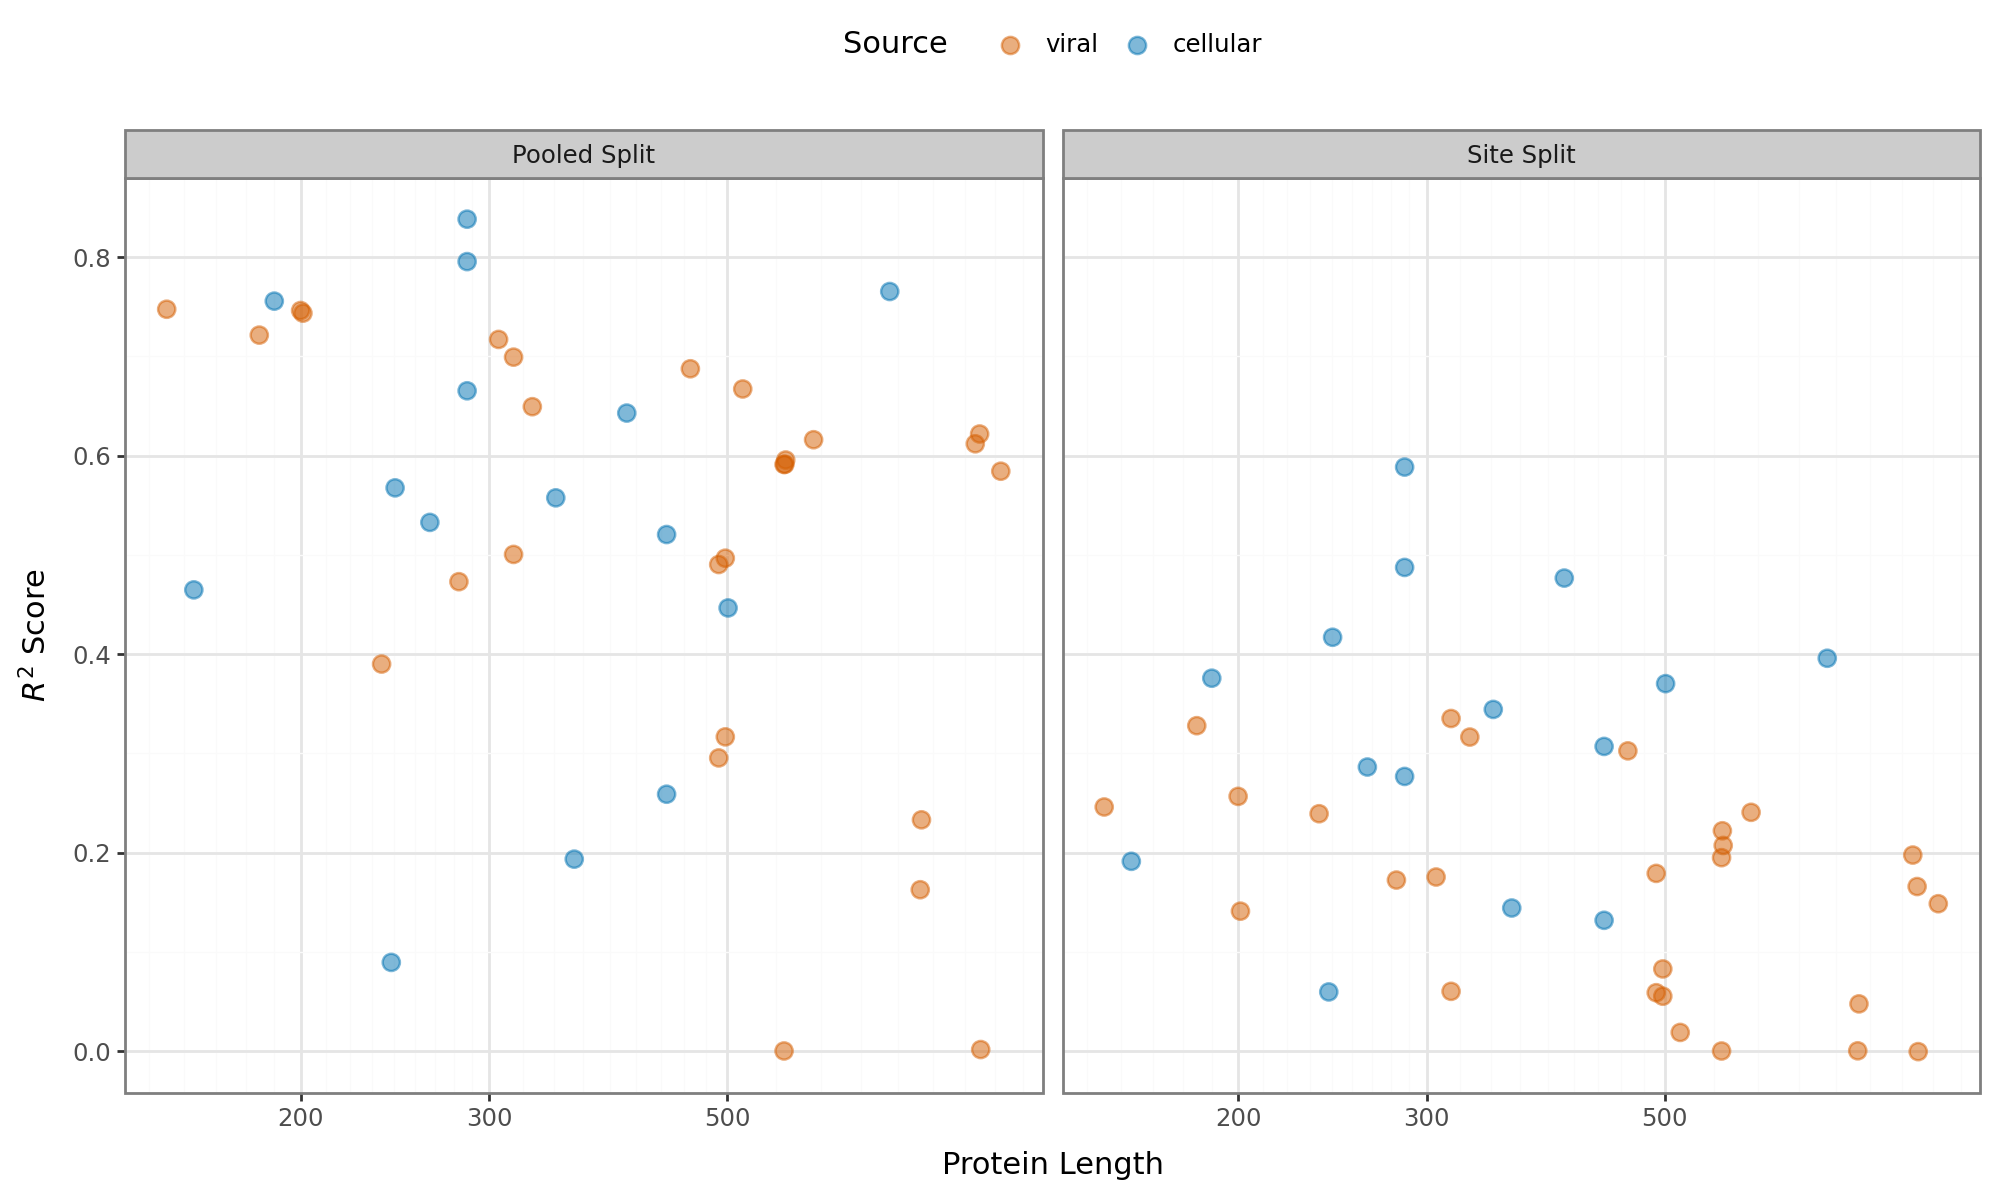

In [18]:
plot = (
    pln.ggplot(res_full, pln.aes(x='protein_length', y='val_r2'))
    + pln.geom_point(pln.aes(color='Source'), size=3, alpha=0.5)
    + pln.scale_color_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.facet_wrap('Split')
    + pln.scale_x_log10()
    + pln.labs(x="Protein Length", y="$R^2$ Score")
    + pln.theme_bw()
    + pln.theme(figure_size=(10, 6), legend_position='top',)

)
plot#.save(filename='../experiments/protein_length_vs_lassocv_r2_full.png', dpi=600)

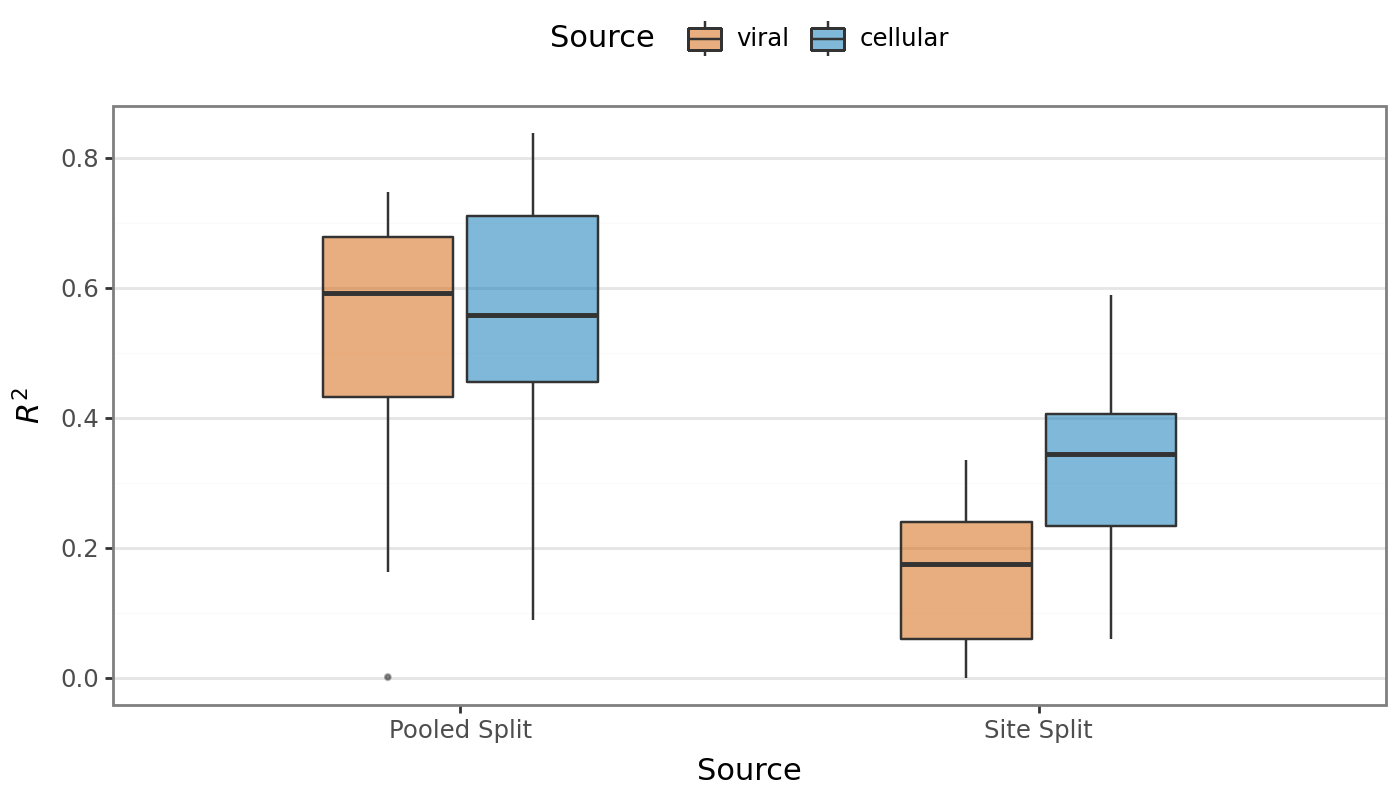

In [19]:
plot = (
    pln.ggplot(res_full, pln.aes(x='Split', y='val_r2'))
    + pln.geom_boxplot(pln.aes(fill='Source'), outlier_size=0.5, outlier_alpha=0.3, alpha=0.5, width=0.5)
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.labs(
        x='Source',
        y='$R^2$',
    )
    + pln.theme_bw()
    + pln.theme(
        legend_position='top',
        figure_size=(7, 4),
        panel_grid_major_x=pln.element_blank(),
    )
    #+ pln.facet_wrap('Split', ncol=2, scales='free_y')
)

plot#.save('../experiments/fineTune/res_finetune_esm2.png', dpi=600)

# LassoCV x finetune

In [21]:
tuned = pd.read_csv('../experiments/compiled_results/res_finetune_esm2_650m_v01.1.csv', index_col=0)
tuned['Model'] = 'ESM-2 650M Tuned'
tuned

,Model,Source,Dataset,Split,train_loss,train_r2,train_rho,val_loss,val_r2,val_rho,protein_length,sample_size
0,ESM-2 650M Tuned,viral,CVB3_2A_Alvarez,Pooled Split,0.308752,0.834837,0.781298,0.442821,0.747517,0.788488,150,2992
1,ESM-2 650M Tuned,viral,CVB3_2A_Alvarez,Site Split,0.822546,0.551201,0.606760,1.437517,0.245925,0.403961,150,2992
2,ESM-2 650M Tuned,viral,CVB3_2C_Alvarez,Pooled Split,0.296652,0.832004,0.818739,0.628615,0.649322,0.759842,329,6573
3,ESM-2 650M Tuned,viral,CVB3_2C_Alvarez,Site Split,0.665937,0.621560,0.740885,1.228748,0.316397,0.574843,329,6573
4,ESM-2 650M Tuned,viral,CVB3_3C_Alvarez,Pooled Split,0.229264,0.856472,0.790496,0.432482,0.721452,0.717907,183,3654
...,...,...,...,...,...,...,...,...,...,...,...,...
79,ESM-2 650M Tuned,cellular,TPK1_HUMAN_Roth2017,Site Split,0.242103,0.149585,0.352113,0.272446,0.059552,0.328397,243,3424
80,ESM-2 650M Tuned,cellular,TPMT_HUMAN_Fowler2018,Pooled Split,0.056472,0.597061,0.637980,0.062675,0.567509,0.652062,245,3984
81,ESM-2 650M Tuned,cellular,TPMT_HUMAN_Fowler2018,Site Split,0.059814,0.574509,0.627595,0.083827,0.416951,0.591066,245,3984
82,ESM-2 650M Tuned,cellular,UBC9_HUMAN_Roth2017,Pooled Split,0.094153,0.624977,0.808222,0.136378,0.464711,0.729119,159,2722


In [22]:
tuned.query('Split == "Pooled Split"').groupby(['Source']).size()

Source
cellular    15
viral       27
dtype: int64

In [23]:
cols = ['Source', 'Split', 'Dataset', 'R2_score_test']
lassocv = pd.read_csv('../experiments/compiled_results/res_lassoCV_esm2_650m_v03.csv', index_col=0)
lassocv['Source'] = pd.Categorical(lassocv['Source'], categories=['viral', 'cellular'])
lassocv = lassocv[cols]
lassocv

,Source,Split,Dataset,R2_score_test
296,cellular,Pooled Split,AMIE_PSEAE_Whitehead,0.486188
297,cellular,Site Split,AMIE_PSEAE_Whitehead,0.231793
298,cellular,Pooled Split,B3VI55_LIPSTSTABLE,0.468531
299,cellular,Site Split,B3VI55_LIPSTSTABLE,0.243568
300,cellular,Pooled Split,B3VI55_LIPST_Whitehead2015,0.256701
...,...,...,...,...
439,viral,Site Split,SARS2_RBD_binding_Starr,0.033222
440,viral,Pooled Split,SARS2_RBD_expression_Starr,0.574433
441,viral,Site Split,SARS2_RBD_expression_Starr,0.034882
442,viral,Pooled Split,SARS2_XBB15_RBD_Taylor,-0.196764


In [24]:
res = tuned.merge(lassocv, on=['Source', 'Split', 'Dataset'])
res.rename(columns={'R2_score_test' : 'lassocv_R2_test'}, inplace=True)
res

,Model,Source,Dataset,Split,train_loss,train_r2,train_rho,val_loss,val_r2,val_rho,protein_length,sample_size,lassocv_R2_test
0,ESM-2 650M Tuned,viral,CVB3_2A_Alvarez,Pooled Split,0.308752,0.834837,0.781298,0.442821,0.747517,0.788488,150,2992,0.583931
1,ESM-2 650M Tuned,viral,CVB3_2A_Alvarez,Site Split,0.822546,0.551201,0.606760,1.437517,0.245925,0.403961,150,2992,0.185763
2,ESM-2 650M Tuned,viral,CVB3_2C_Alvarez,Pooled Split,0.296652,0.832004,0.818739,0.628615,0.649322,0.759842,329,6573,0.456154
3,ESM-2 650M Tuned,viral,CVB3_2C_Alvarez,Site Split,0.665937,0.621560,0.740885,1.228748,0.316397,0.574843,329,6573,0.273652
4,ESM-2 650M Tuned,viral,CVB3_3C_Alvarez,Pooled Split,0.229264,0.856472,0.790496,0.432482,0.721452,0.717907,183,3654,0.493281
...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,ESM-2 650M Tuned,cellular,TPK1_HUMAN_Roth2017,Site Split,0.242103,0.149585,0.352113,0.272446,0.059552,0.328397,243,3424,0.075768
80,ESM-2 650M Tuned,cellular,TPMT_HUMAN_Fowler2018,Pooled Split,0.056472,0.597061,0.637980,0.062675,0.567509,0.652062,245,3984,0.458016
81,ESM-2 650M Tuned,cellular,TPMT_HUMAN_Fowler2018,Site Split,0.059814,0.574509,0.627595,0.083827,0.416951,0.591066,245,3984,0.274008
82,ESM-2 650M Tuned,cellular,UBC9_HUMAN_Roth2017,Pooled Split,0.094153,0.624977,0.808222,0.136378,0.464711,0.729119,159,2722,0.403438


/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 8 x 4.5 in image.
/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: ../experiments/figures/finetune_x_lassoCV_v01.1.png
/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:372: PlotnineWarning: geom_point : Removed 4 rows containing missing values.
/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:372: PlotnineWarning: geom_point : Removed 4 rows containing missing values.


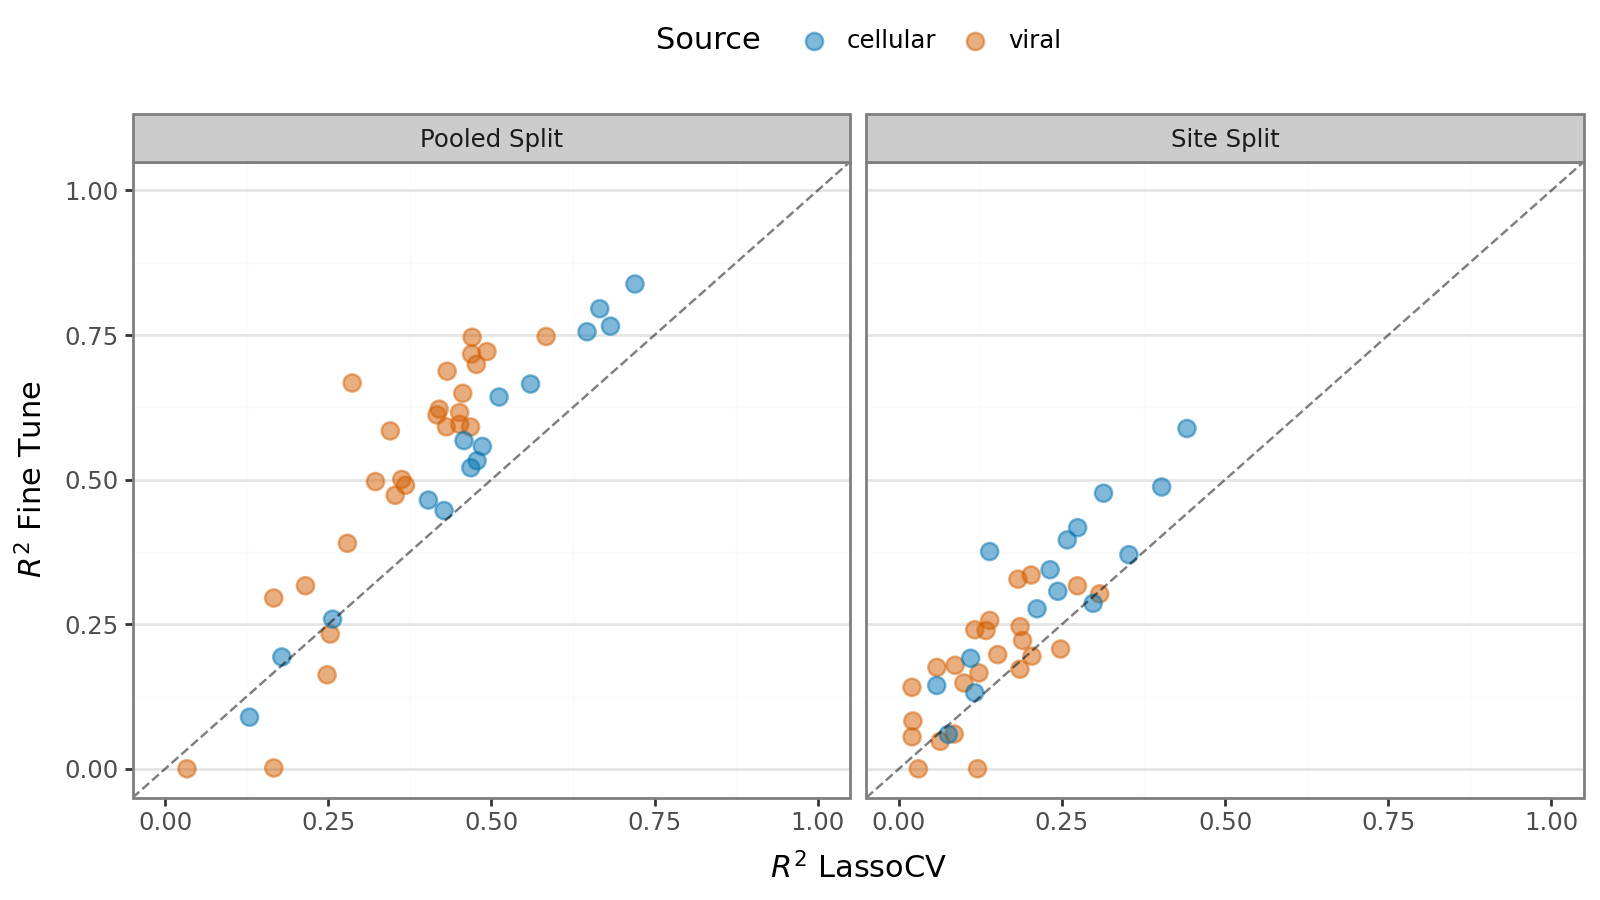

In [26]:
plot = (
    pln.ggplot(res, pln.aes(x='lassocv_R2_test', y='val_r2'))
    + pln.geom_point(pln.aes(color='Source'), size=3, alpha=0.5)
    + pln.scale_color_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_abline(intercept=0, alpha=0.5, linetype='dashed')
    + pln.theme_bw()
    + pln.theme(
        figure_size=(8, 4.5),
        panel_grid_major_x=pln.element_blank(),
        legend_position='top'
    )
    + pln.facet_wrap('Split', ncol=2)
    + pln.labs(
        x='$R^2$ LassoCV',
        y='$R^2$ Fine Tune',
    )
    +pln.ylim(0,1)
    +pln.xlim(0,1)
)

plot.save('../experiments/figures/finetune_x_lassoCV_v01.1.png', dpi=600)
plot